# Unemployment Analysis with Python

## Objective

The objective of this project is to analyze unemployment data using Python and understand unemployment trends across different regions and time periods.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv(r"C:\Users\Sharayu\Downloads\archive\Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (768, 7)


In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [8]:
df = df.dropna()

print("Dataset shape after removing missing values:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Dataset shape after removing missing values: (740, 7)

Missing values after cleaning:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64


In [9]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print(df.dtypes)

KeyError: 'Date'

In [10]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [11]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Check the data types
print(df.dtypes)

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object


In [12]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

print(region_avg)

Region
Andhra Pradesh       7.477143
Assam                6.428077
Bihar               18.918214
Chandigarh          15.991667
Chhattisgarh         9.240357
Delhi               16.495357
Goa                  9.274167
Gujarat              6.663929
Haryana             26.283214
Himachal Pradesh    18.540357
Jammu & Kashmir     16.188571
Jharkhand           20.585000
Karnataka            6.676071
Kerala              10.123929
Madhya Pradesh       7.406429
Maharashtra          7.557500
Meghalaya            4.798889
Odisha               5.657857
Puducherry          10.215000
Punjab              12.031071
Rajasthan           14.058214
Sikkim               7.249412
Tamil Nadu           9.284286
Telangana            7.737857
Tripura             28.350357
Uttar Pradesh       12.551429
Uttarakhand          6.582963
West Bengal          8.124643
Name: Estimated Unemployment Rate (%), dtype: float64


In [13]:
# Sort regions by average unemployment rate
top_regions = region_avg.sort_values(ascending=False).head(10)

print("Top 10 Regions with Highest Average Unemployment Rate:")
print(top_regions)

Top 10 Regions with Highest Average Unemployment Rate:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


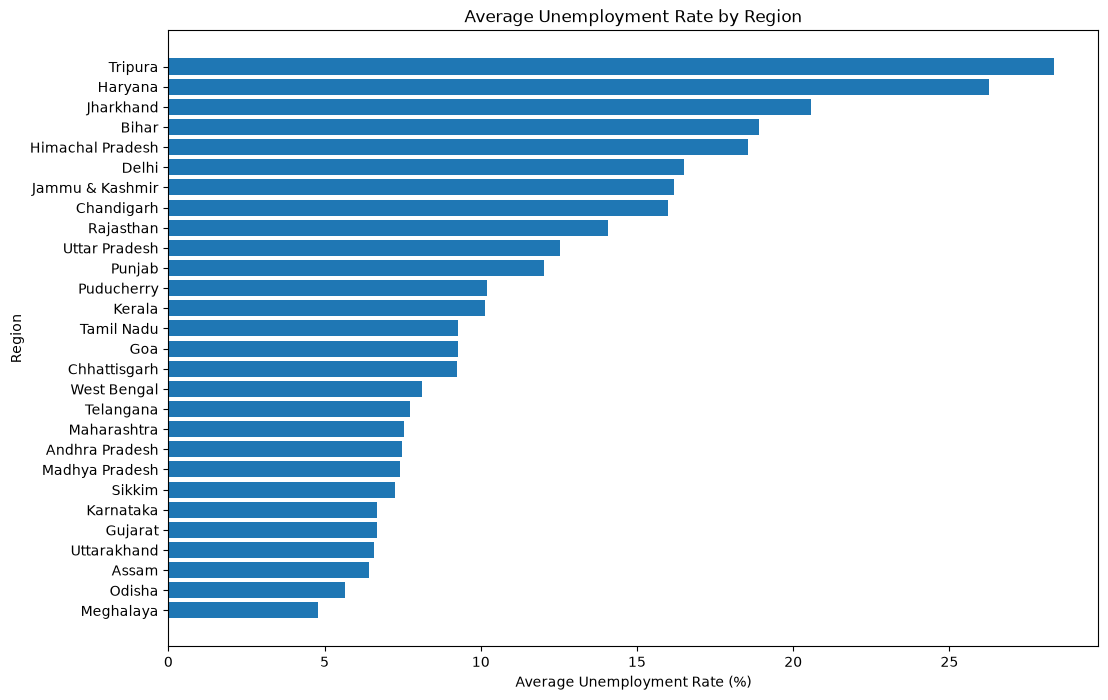

In [14]:
# Sort regions by average unemployment rate
region_avg_sorted = region_avg.sort_values(ascending=False)

# Plot the results
plt.figure(figsize=(12, 8))

plt.barh(
    region_avg_sorted.index,
    region_avg_sorted.values
)

plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.title("Average Unemployment Rate by Region")

plt.gca().invert_yaxis()

plt.show()

## Unemployment Trend Over Time

This analysis shows how the average unemployment rate changed over different time periods.

In [15]:
# Calculate average unemployment rate for each date
time_trend = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

print(time_trend)

Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64


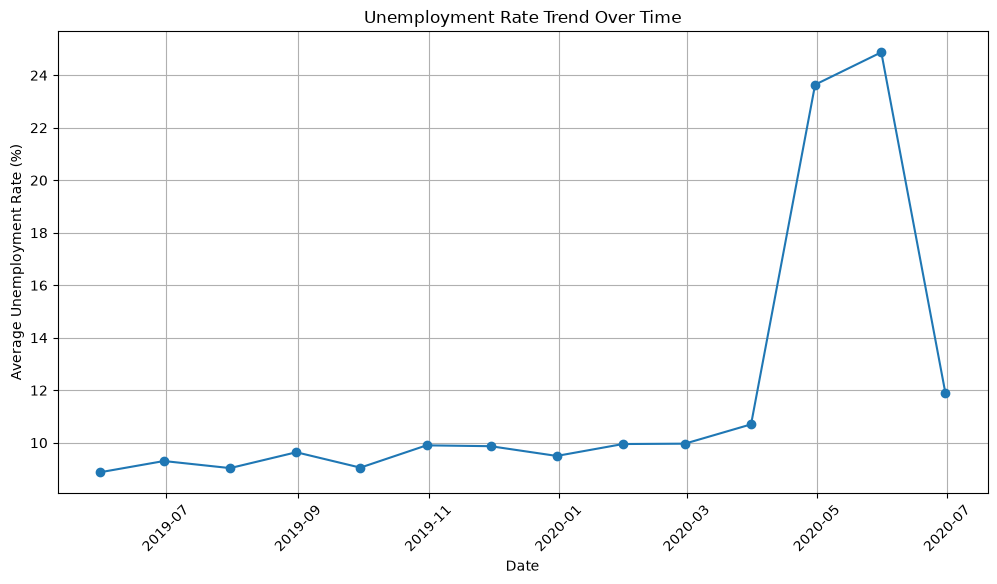

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    time_trend.index,
    time_trend.values,
    marker="o"
)

plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

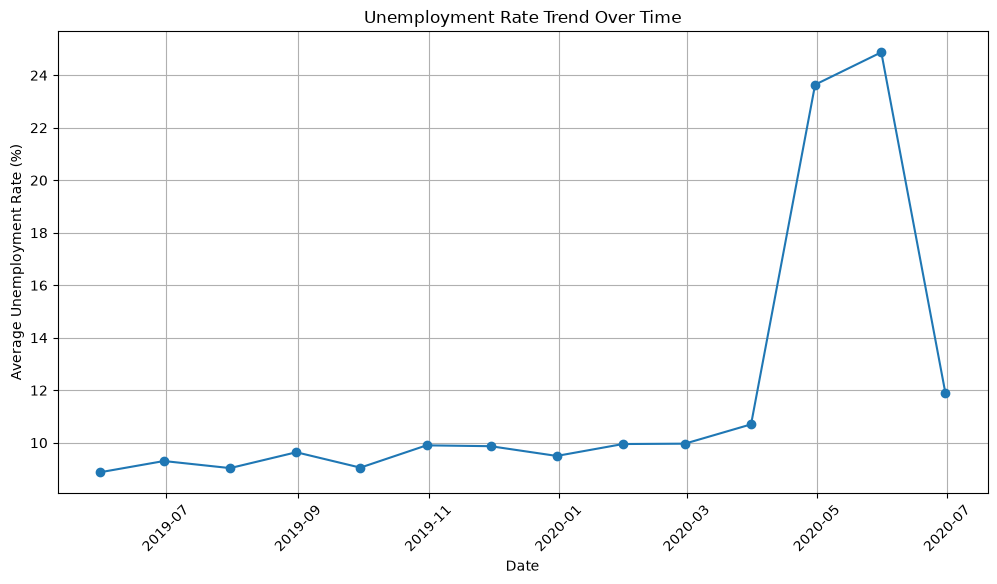

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    time_trend.index,
    time_trend.values,
    marker="o"
)

plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [18]:
# Calculate average unemployment rate for each area
area_avg = df.groupby("Area")["Estimated Unemployment Rate (%)"].mean()

print(area_avg)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


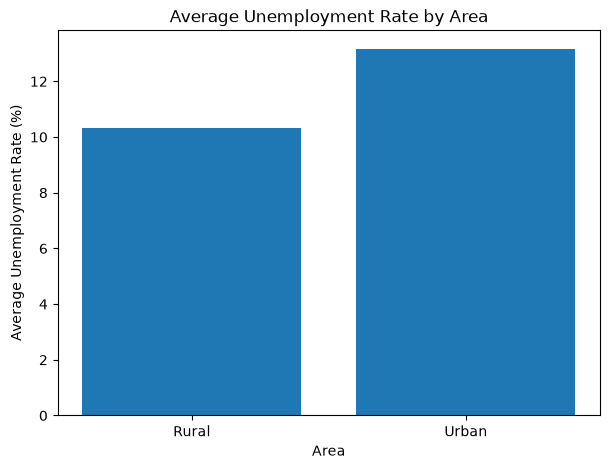

In [19]:
# Plot average unemployment rate by area

plt.figure(figsize=(7, 5))

plt.bar(
    area_avg.index,
    area_avg.values
)

plt.title("Average Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

In [20]:
# Find the region with the highest and lowest average unemployment rate

highest_region = region_avg.idxmax()
highest_rate = region_avg.max()

lowest_region = region_avg.idxmin()
lowest_rate = region_avg.min()

print("Region with Highest Average Unemployment Rate:")
print(highest_region, "-", round(highest_rate, 2), "%")

print("\nRegion with Lowest Average Unemployment Rate:")
print(lowest_region, "-", round(lowest_rate, 2), "%")

Region with Highest Average Unemployment Rate:
Tripura - 28.35 %

Region with Lowest Average Unemployment Rate:
Meghalaya - 4.8 %


In [21]:
# Find the region with the highest average unemployment rate
highest_unemployment = region_avg.idxmax()
highest_rate = region_avg.max()

# Find the region with the lowest average unemployment rate
lowest_unemployment = region_avg.idxmin()
lowest_rate = region_avg.min()

print("Region with Highest Average Unemployment Rate:")
print(highest_unemployment, ":", round(highest_rate, 2), "%")

print("\nRegion with Lowest Average Unemployment Rate:")
print(lowest_unemployment, ":", round(lowest_rate, 2), "%")

Region with Highest Average Unemployment Rate:
Tripura : 28.35 %

Region with Lowest Average Unemployment Rate:
Meghalaya : 4.8 %


In [24]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

In [25]:
# Correlation between numerical variables

correlation = df.corr(numeric_only=True)

print(correlation)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


In [26]:
area_avg = df.groupby("Area")["Estimated Unemployment Rate (%)"].mean()

print("Average Unemployment Rate by Area:")
print(area_avg)

Average Unemployment Rate by Area:
Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


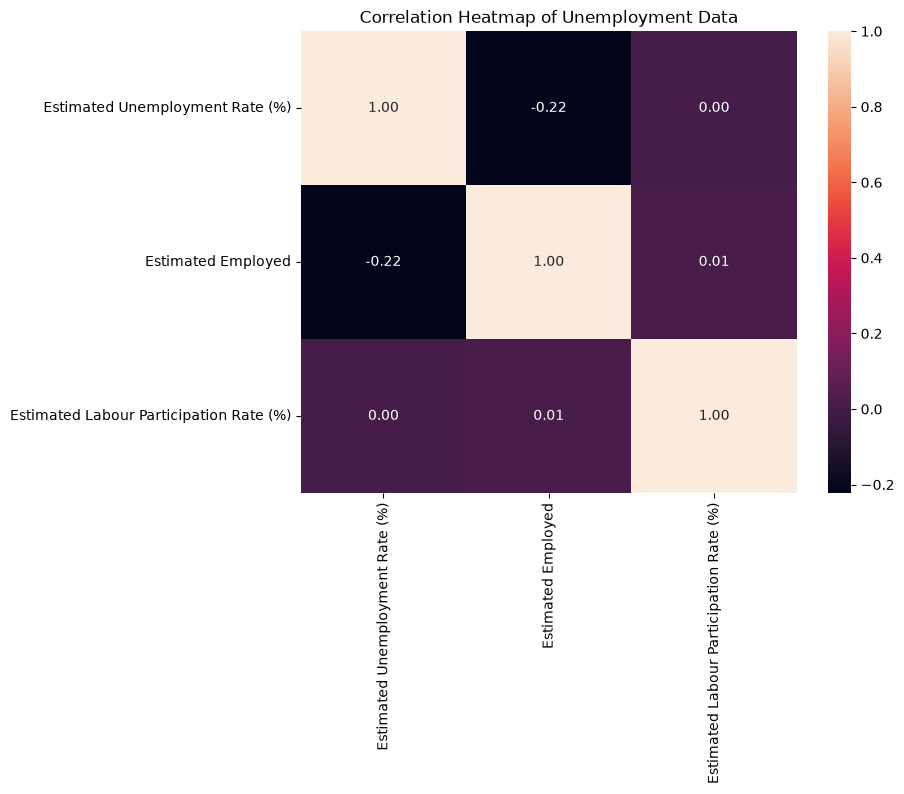

In [27]:
# Calculate correlation between numerical columns
correlation = df.corr(numeric_only=True)

# Plot correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Unemployment Data")
plt.show()

In [28]:
# Divide the data into Pre-COVID and COVID periods

df["Period"] = df["Date"].apply(
    lambda date: "Pre-COVID" if date < pd.Timestamp("2020-03-01") else "COVID Period"
)

# Calculate average unemployment rate for each period
covid_comparison = df.groupby("Period")["Estimated Unemployment Rate (%)"].mean()

print("Average Unemployment Rate:")
print(covid_comparison)

Average Unemployment Rate:
Period
COVID Period    17.774363
Pre-COVID        9.509534
Name: Estimated Unemployment Rate (%), dtype: float64


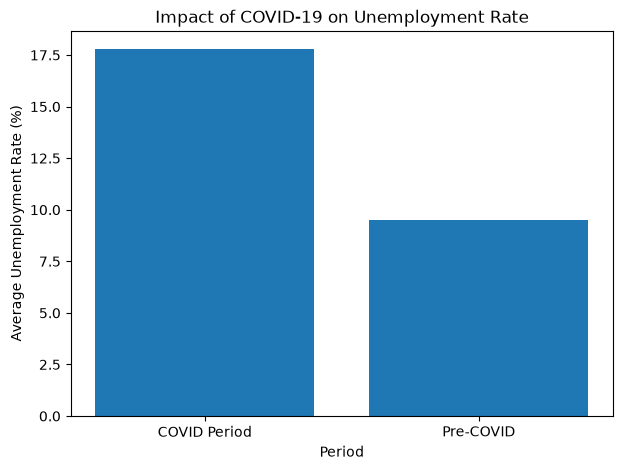

In [29]:
# Visualize unemployment before and during COVID-19

plt.figure(figsize=(7, 5))

plt.bar(covid_comparison.index, covid_comparison.values)

plt.title("Impact of COVID-19 on Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

## Key Insights

- The unemployment rate varied significantly across different regions of India.
- Tripura recorded the highest average unemployment rate at approximately 28.35%.
- Meghalaya recorded the lowest average unemployment rate at approximately 4.80%.
- The average unemployment rate was higher in urban areas (13.17%) compared with rural areas (10.32%).
- The unemployment rate showed a sharp increase during April–May 2020.
- The comparison between the Pre-COVID and COVID periods indicates that unemployment was higher during the COVID period in this dataset.

## Conclusion

This project analyzed unemployment trends in India using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The analysis showed significant differences in unemployment rates across regions and between rural and urban areas. Tripura had the highest average unemployment rate, while Meghalaya had the lowest.

The time-series analysis showed a noticeable increase in unemployment around April–May 2020. The comparison between the Pre-COVID and COVID periods also showed a higher average unemployment rate during the COVID period in this dataset.

Overall, the project helped identify regional, geographical, and time-based patterns in unemployment and demonstrated how data analysis and visualization can be used to understand real-world economic data.